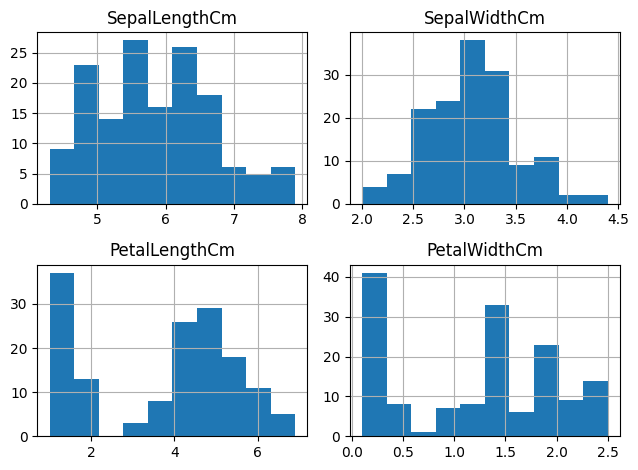

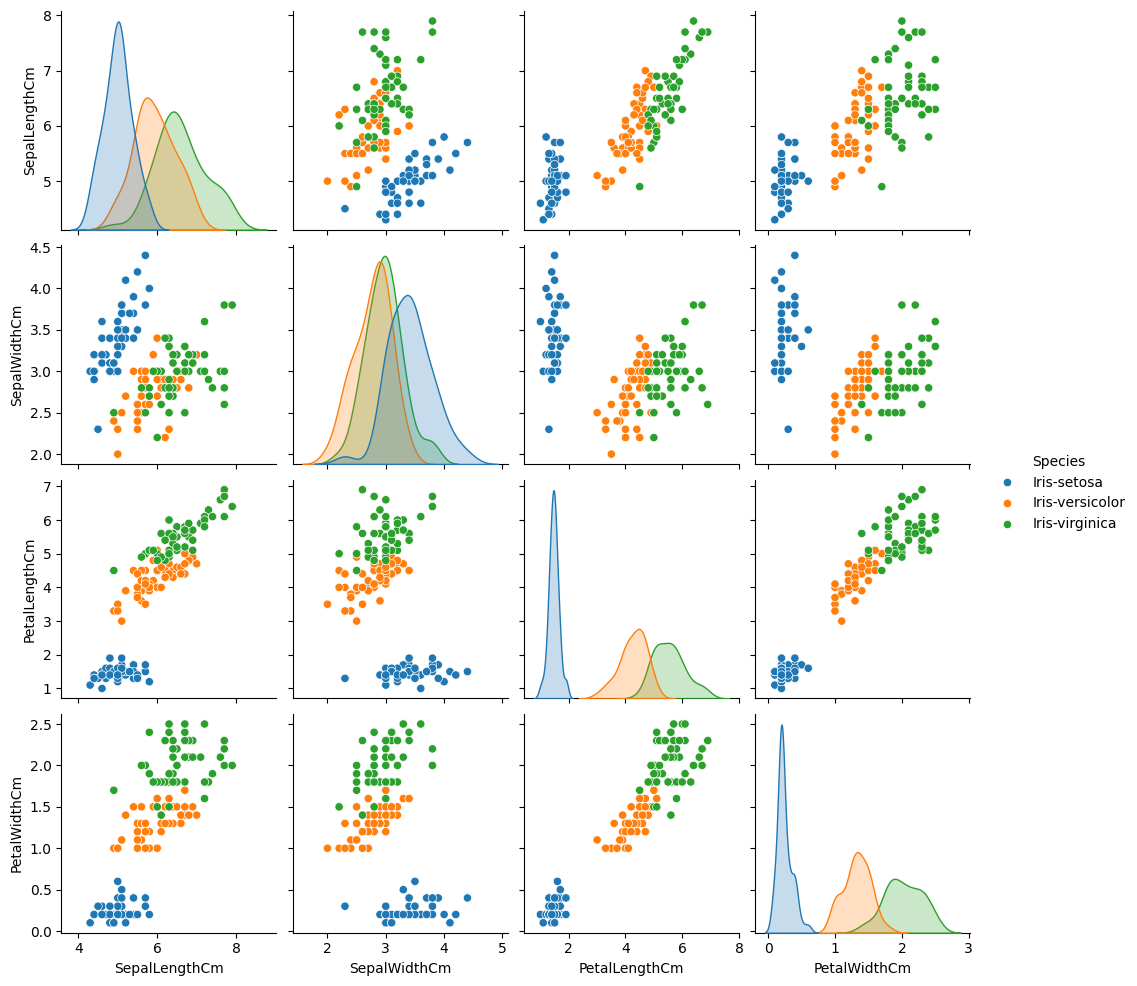

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/002-iris.csv").set_index("Id")
df.hist()
plt.tight_layout()

sns.pairplot(data=df, hue="Species")

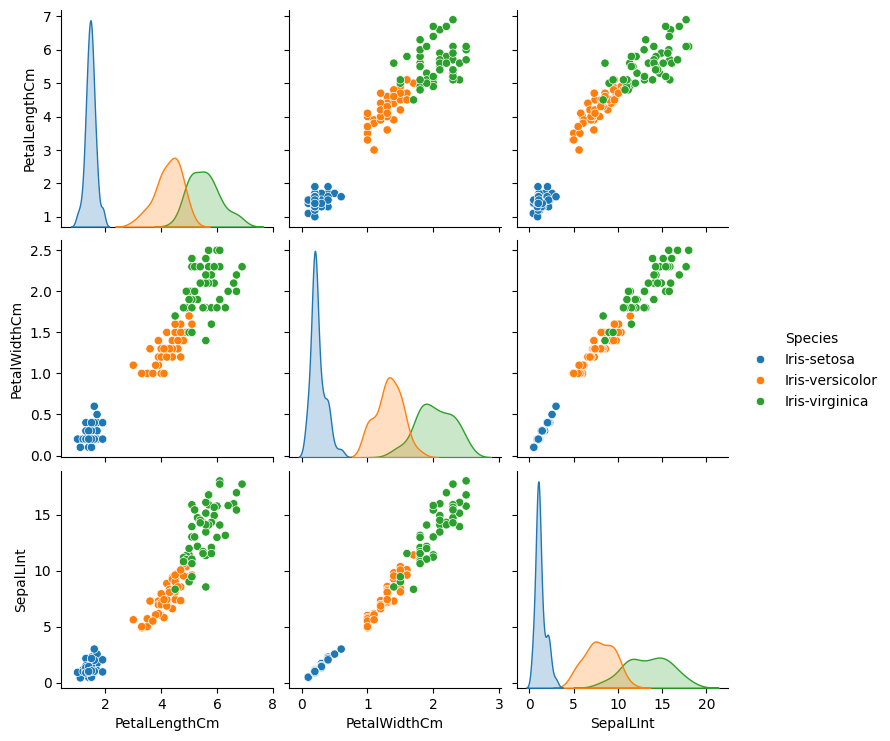

In [2]:
dft = pd.DataFrame()

dft["PetalLengthCm"] = df["PetalLengthCm"]
dft["PetalWidthCm"] = df["PetalWidthCm"]
dft["SepalLInt"] = df["SepalLengthCm"] * df["PetalWidthCm"]
# dft["AreaRatio"] = (df["PetalLengthCm"] * df["PetalWidthCm"]) / (df["SepalLengthCm"] * df["SepalWidthCm"])

dft["Species"] = df["Species"]

sns.pairplot(dft, hue="Species")

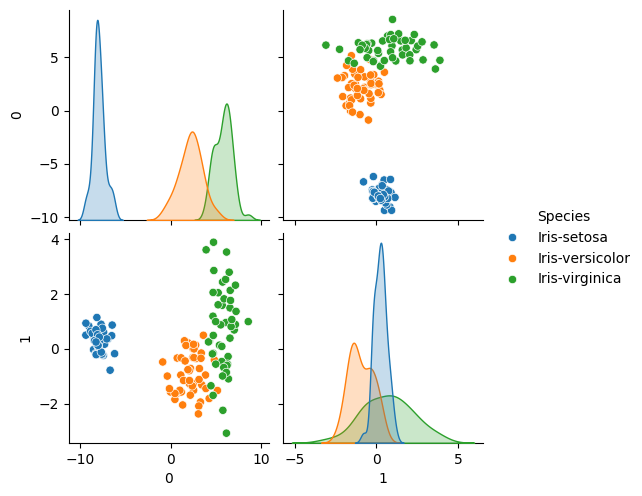

In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(dft.iloc[:, :-1], dft.iloc[:, -1])
xlda = pd.DataFrame(lda.transform(dft.iloc[:, :-1]), index=dft.index)

dflda = xlda.join(dft.iloc[:, -1])
sns.pairplot(data=dflda, hue="Species")
# plt.tight_layout()

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import numpy as np

pipe = make_pipeline(
    LinearDiscriminantAnalysis(),
    SVC(),
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

gscv = GridSearchCV(
    estimator=pipe,
    param_grid={
        "lineardiscriminantanalysis__n_components": [1, 2],
        "svc__C": [1.4873521072935114],
        "svc__gamma": [0.005736152510448681],
    },
    cv=skf
)
gscv.fit(dft.iloc[:, :-1], dft.iloc[:, -1])
bestmodel = gscv.best_estimator_
print(gscv.best_params_)
print(gscv.best_score_)

{'lineardiscriminantanalysis__n_components': 1, 'svc__C': 1.4873521072935114, 'svc__gamma': 0.005736152510448681}
0.9733333333333334
